# Clean & Analyze Social Media Data

## Introduction

Social media has become a ubiquitous part of modern life, with platforms such as Instagram, Twitter, and Facebook serving as essential communication channels. Social media data sets are vast and complex, making analysis a challenging task for businesses and researchers alike. 

In this project, we explore a simulated social media, for example Tweets, data set to understand trends in likes across different categories.

## Prerequisites

To follow along with this project, you should have a basic understanding of Python programming and data analysis concepts. In addition, you may want to use the following packages in your Python environment:

- pandas
- Matplotlib
- ...

These packages should already be installed in Coursera's Jupyter Notebook environment, however if you'd like to install additional packages that are not included in this environment or are working off platform you can install additional packages using `!pip install packagename` within a notebook cell such as:

- `!pip install pandas`
- `!pip install matplotlib`

## Project Scope

The objective of this project is to analyze tweets (or other social media data) and gain insights into user engagement. We will explore the data set using visualization techniques to understand the distribution of likes across different categories. Finally, we will analyze the data to draw conclusions about the most popular categories and the overall engagement on the platform.

## Step 1: Importing Required Libraries

As the name suggests, the first step is to import all the necessary libraries that will be used in the project. In this case, we need pandas, numpy, matplotlib, seaborn, and random libraries.

- Pandas is a library used for data manipulation and analysis. 
- Numpy is a library used for numerical computations. 
- Matplotlib is a library used for data visualization. 
- Seaborn is a library used for statistical data visualization. 
- Random is a library used to generate random numbers.
- Datetime
- CSV

In [ ]:
%pip install seaborn datetime
import pandas as pd #why?
import numpy as np #why?
import matplotlib.pyplot as plt #why?
import seaborn as sns #why?
from numpy import random #why?
import datetime
import csv

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached datetime-6.0-py3-none-any.whl.metadata (34 kB)

   ---------------------------------------- 0/4 [pytz]
   ---------------------------------------- 0/4 [pytz]
   ---------------------------------------- 0/4 [pytz]
   ---------- ----------------------------- 1/4 [zope.interface]
   ---------- ----------------------------- 1/4 [zope.interface]
   ---------- ----------------------------- 1/4 [zope.interface]
   ---------- ----------------------------- 1/4 [zope.interface]
   -------------------- ------------------- 2/4 [datetime]
   ------------------------------ --------- 3/4 [seaborn]
   ------------------------------ --------- 3/4 [seaborn]
   ------------------------------ --------- 3/4 [seaborn]
   ------------------------------ --------- 3/4 [seaborn]
   ------------------------------ --------- 3/4 [seaborn]
   ---------------------------------------- 4/4 [seaborn]



## Step 2: Generate random data for the social media data

First we will define `category` as per the instruction to include categories of post - fitness, tech, family, beuty etc. Then we will define start date and end date for the duration over which social media data is spread. I have used first day of the 2026 upto the day this notebook will be run. The code I have written creates this data and saves it in `smda3.csv`. Please note the analysis is done on `smda.csv` for time being to make sure we aren't generating new dummy data everytime we run this notebook to make analysis convenient.

In [9]:
category = ["fitness", "tech", "family", "beauty"]
start_date = datetime.date(2026,1,1).toordinal()
end_date = datetime.date.today().toordinal()
with open('smda3.csv', 'w') as f:
    writer = csv.writer(f)
    writer.writerow(['Date', 'Category', 'Likes'])
    for i in range(501):
        post_date = datetime.date.fromordinal(random.randint(start_date, end_date))
        post_category = category[random.randint(0,4)]
        post_likes = random.randint(0, 10000)
        writer.writerow([post_date, post_category, post_likes])

## Step 3: Load the data into a Pandas DataFrame and Explore the data
The data can be loaded into the Pandas DataFrame using a single command as below. 
- `df = pd.read_csv('smda.csv')`

Later, we can explore the data using following three commands.
- `print(df.head())`.
- `print(df.info())`.
- `print(df.describe())`.

The data can be sorted by Date column for convenience.
 - `df.sort_values('Date')`

In [10]:
df = pd.read_csv('smda.csv')

print('The first 5 rows of the data are as follows:')
print(df.head())
print() # This prints blank line
print("The following will tell us about the non-null values and data types:")
print(df.info(), end ="\n\n")
print("Summary statistics:")
print(df.describe())

The first 5 rows of the data are as follows:
         Date Category  Likes
0  2026-01-22   family   9714
1  2026-01-25   family   1194
2  2026-03-06     tech   2251
3  2026-03-09     tech   2675
4  2026-03-22     tech   4885

The following will tell us about the non-null values and data types:
<class 'pandas.DataFrame'>
RangeIndex: 501 entries, 0 to 500
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Date      501 non-null    str  
 1   Category  501 non-null    str  
 2   Likes     501 non-null    int64
dtypes: int64(1), str(2)
memory usage: 11.9 KB
None

Summary statistics:
             Likes
count   501.000000
mean   5011.051896
std    2962.292208
min      12.000000
25%    2443.000000
50%    5060.000000
75%    7608.000000
max    9982.000000


## Step 4: Clean the data

### 4.1: Check for null data

In [11]:
#Is there null data?
print("The following will tell us about the non-null values and data types:")
print(df.info()) #All 501 values are non-null as per df.info() result

The following will tell us about the non-null values and data types:
<class 'pandas.DataFrame'>
RangeIndex: 501 entries, 0 to 500
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Date      501 non-null    str  
 1   Category  501 non-null    str  
 2   Likes     501 non-null    int64
dtypes: int64(1), str(2)
memory usage: 11.9 KB
None


### 4.2: Check for duplicates

Pandas DataFrame has handy command `df.duplicated()` to check for duplicates.

In [12]:
#sorts data as per number of likes
df = df.sort_values('Likes')

#Is there duplicate data?
duplicate_rows = df[df.duplicated()]
print(duplicate_rows)

duplicate_subset = df[df.duplicated(subset=['Category', 'Likes'], keep=False)]
print(duplicate_subset)
print("\n\nThere are posts within same category which received same number of likes but they were posted on different dates")
#No duplicates, there are posts within same category which received same number of likes but they were posted on different dates

Empty DataFrame
Columns: [Date, Category, Likes]
Index: []
           Date Category  Likes
242  2026-01-06     tech   1125
166  2026-03-18     tech   1125
26   2026-03-02   family   3322
466  2026-04-16   family   3322
415  2026-01-21     tech   3504
224  2026-04-07     tech   3504


There are posts within same category which received same number of likes but they were posted on different dates


### 4.3: Change Date field type

It's better to convert the Date field of dataframe to a `datetime64` format using the pandas for easier analysis as it gives pandas a calendar instead of just a list of words when type is `object`.

In [13]:
#convert the Date dataframe field to a datetime format using the pandas object
df['Date'] = pd.to_datetime(df['Date'])

#sorts data as per Date
df = df.sort_values('Date')

print(df.info()) # You can see now Date is datetime64 instead of object

<class 'pandas.DataFrame'>
Index: 501 entries, 68 to 481
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      501 non-null    datetime64[us]
 1   Category  501 non-null    str           
 2   Likes     501 non-null    int64         
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 15.7 KB
None


## Step 5: Visualize and Analyze the data
- Distribution across catergories
- Distribution of number of likes in each category
- Bar chart of total likes over time (across months)
- Bar chart (clustered) of total likes over time (across months and categories)
- Histogram of likes for each category

### 5.1: Distribution across catergories

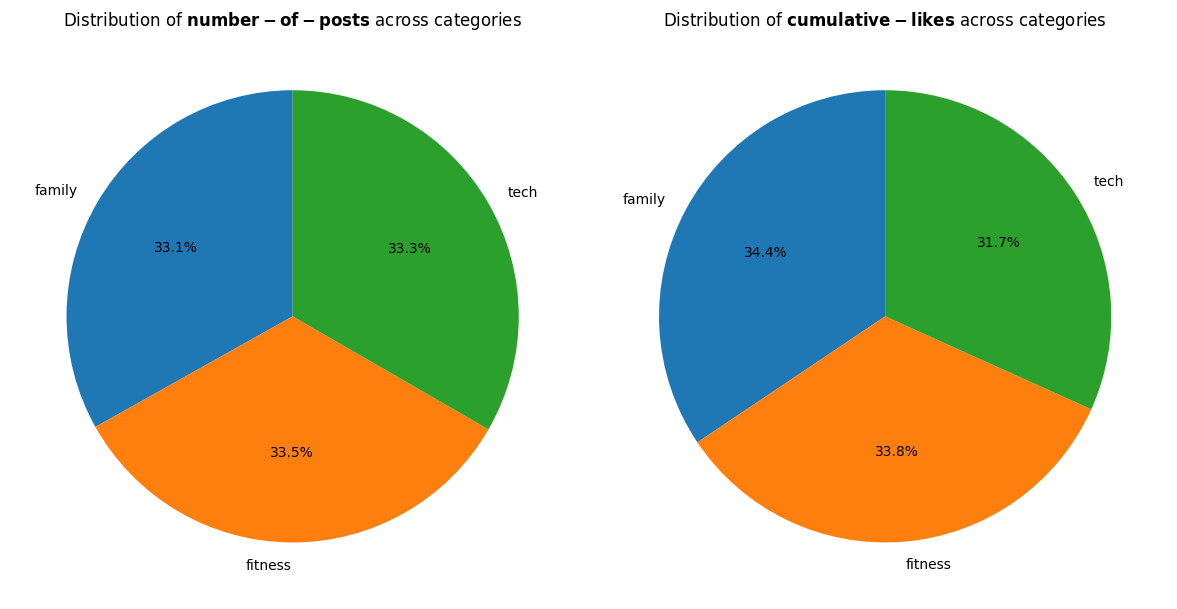

In [14]:
cat_count = df['Category'].value_counts().sort_index()
cat_sum = df.groupby('Category')['Likes'].sum().sort_index()

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6))
ax1.pie(cat_count, labels=cat_count.index, autopct='%1.1f%%', startangle=90)
ax1.set_title(r'Distribution of $\mathbf{number-of-posts}$ across categories')
ax2.pie(cat_sum, labels=cat_sum.index, autopct='%1.1f%%', startangle=90)
ax2.set_title(r'Distribution of $\mathbf{cumulative-likes}$ across categories')
plt.tight_layout()
plt.show()

### 5.2: Distribution of number of likes in each category
Box plot shows spread, median, and outliers

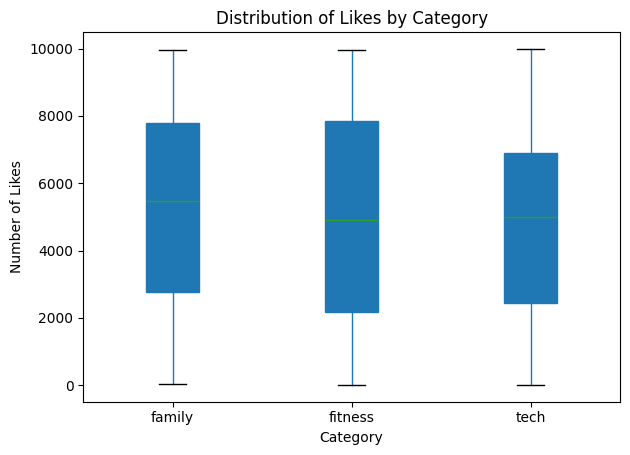

In [15]:
df.boxplot(column='Likes', by='Category', grid=False, patch_artist=True)

#Add styling
plt.title('Distribution of Likes by Category')
plt.suptitle('')  # Removes the default "Boxplot grouped by..." header
plt.xlabel('Category')
plt.ylabel('Number of Likes')

#Save the plot
plt.tight_layout()

### 5.3: Bar chart of total likes over time (across months)

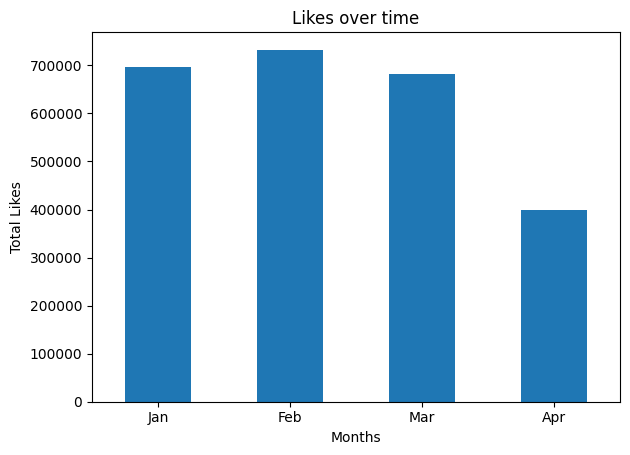

In [16]:
monthly_likes = df.groupby(df['Date'].dt.to_period('M'))['Likes'].sum()
monthly_likes.index = monthly_likes.index.to_timestamp().strftime('%b')
monthly_likes.plot(kind='bar')

#Add styling
plt.title('Likes over time')
plt.suptitle('')  # Removes the default "Boxplot grouped by..." header
plt.xlabel('Months')
plt.xticks(rotation=0)
plt.ylabel('Total Likes')

plt.tight_layout()

### 5.4: Bar chart (clustered) of total likes over time (across months and categories)

<Axes: xlabel='Month', ylabel='Likes'>

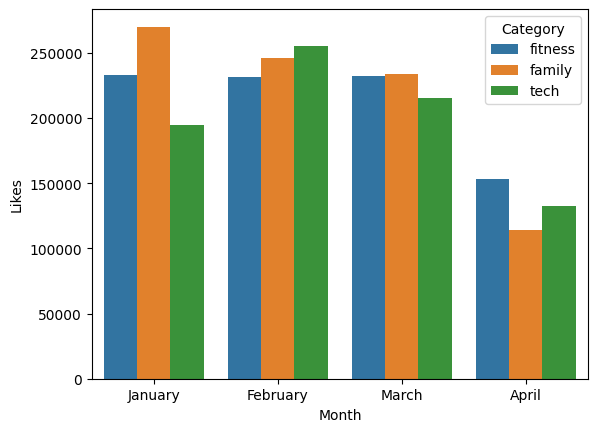

In [17]:
#Extract Month name (or Month number)
df['Month'] = df['Date'].dt.month_name()
monthly_summary = df.groupby(['Month', 'Category'], sort=False)['Likes'].sum().reset_index()
sns.barplot(
    data=monthly_summary, 
    x='Month', 
    y='Likes', 
    hue='Category'
)

### 5.5: Histogram of likes for each category

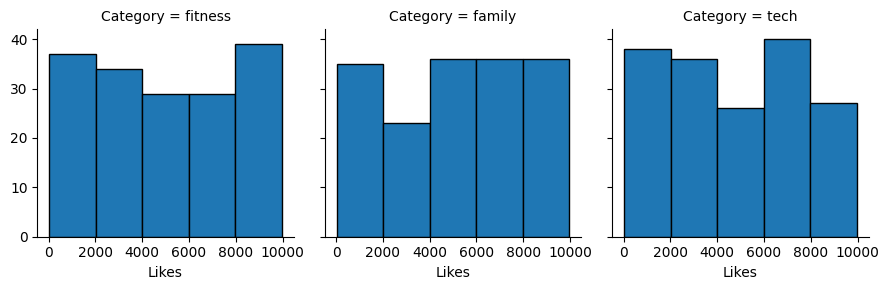

In [18]:
g = sns.FacetGrid(df, col="Category", sharex=True)
g.map(plt.hist, "Likes", bins=5, edgecolor='black')

## Step 6: Describe Conclusions and Notes on Learning
### Conclusion
- Engaged is almost equal across category and across time.
- Usually, distribution is right skewed (majority of likes small in number and few viral likes) but as the data is dummy we didn't see that pattern in engagement.

### Learning
- How I wrote code to generate dummy data (mistake I made and that means no post in beauty category)
- Commands (such as sort_value, count_values, Date dataframe, groupby, and sum etc)

### Future Tasks
- ~Clean up the notebook~
- ~Upload to gitHub~ https://github.com/savan8192/coursera-project
- Write a report
- Days of the week analysis
- Heatmap
- KPI Cards